Several notes on SEI models:
1. In "reaction limited" smallest L_sei_0 can be used is 1e-12.
2. "electron-migration limited" for smalle L_sei_0 produce error and for relatively large L_sei_0 > 4e-9 at some point L_sei decrease. I have noticed tht overpotntial always must be negative [Tang et al. 2012](https://iopscience.iop.org/article/10.1149/2.025211je). So if we make it  postive we get postitive L_sei for any L_sei_0.
3. L_sei in "ec reaction limited" model increase gradually, then nradpidaly, and at some sgate become 

In [1]:
%cd /home/kawamanmi/Projects/PyBaMM
import pybamm
import numpy as np
import matplotlib.pyplot as plt
param = pybamm.ParameterValues("Chen2020")


/home/kawamanmi/Projects/PyBaMM


In [2]:
param['Initial inner SEI thickness [m]'] = 2.5e-9
param['Initial outer SEI thickness [m]'] = 2.5e-9

In [3]:

cycle_no = 2

# stateOfCharge = 0
# exp_CCCV = pybamm.Experiment(
#     [("Charge at C/10 until 4.2 V",
#       "Rest for 5 hours",
#       "Discharge at C/10 until 2.5 V",
#       "Rest for 5 hours",
#       )] * cycle_no
# )
stateOfCharge = 1
exp_CCCV = pybamm.Experiment(
    [("Discharge at C/10 until 2.5 V",
      "Rest for 20 hours",
      "Charge at C/10 until 4.2 V",
      "Rest for 20 hours",
      )] * cycle_no
)

In [4]:
# Diffferent SEI models can be used
sei_model = "interstitial-diffusion limited"
# sei_model = "electron-migration limited"

model = pybamm.lithium_ion.SPM(options={
    "SEI": sei_model,
    "SEI porosity change": "false",
},
    name=sei_model)

In [5]:
solver = pybamm.CasadiSolver(mode="safe")
sim = pybamm.Simulation(model, parameter_values=param,
                        experiment=exp_CCCV, solver=solver)

In [6]:
sol = sim.solve(initial_soc=stateOfCharge)

In [7]:
# Vaiables to be postprocessed, you can add as many as output variables to the following list
# you can find the list variables to be be output by typing model name dot varaible_name() e.g. here, models[0].variable_names()
out_vars = [  # 'X-averaged negative particle surface concentration [mol.m-3]',
    # "Voltage [V]",
    # 'X-averaged negative SEI thickness [m]',
    'Discharge capacity [A.h]'
    # 'Total capacity lost to side reactions [A.h]',
    # 'Loss of lithium to SEI [mol]',
    'Total current density [A.m-2]',
    # 'X-averaged outer SEI thickness [m]',
    # 'X-averaged negative electrode porosity',
]

# Label for the output variables y-axis in the plots
yaxis_labels = ["SEI_thickness",
                'Total capacity lost to side reactions [A.h]', 'Total lithium in particles', 'X-averaged inner SEI thickness [m]',
                'X-averaged outer SEI thickness [m]',]

In [8]:
# from matplotlib import lines

# for sol in sols_SPM:  # loop through the solutions of the DFN models
#     LS_cycles = [sol.cycles[k].steps[2]['X-averaged SEI thickness [m]'].entries[-1]
#                  for k in range(cycle_no)]
#     plt.scatter(np.arange(1, cycle_no+1), LS_cycles,
#                 label=models_SPM[sols_SPM.index(sol)].name)
# plt.xlabel("Cycle number")
# plt.ylabel("SEI thickness [m]")
# plt.legend()
# plt.show()

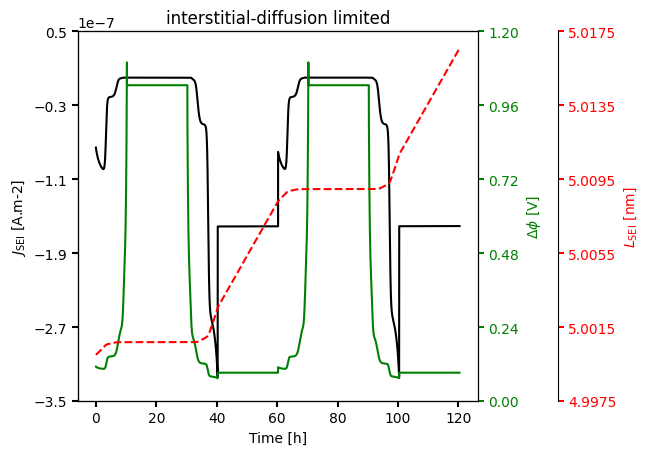

In [9]:
fig, ax = plt.subplots()
fig.subplots_adjust(right=0.75)

twin1 = ax.twinx()
twin2 = ax.twinx()

twin2.spines.right.set_position(("axes", 1.2))

p1, = ax.plot(sol['Time [h]'].entries, sol
              ['X-averaged negative electrode SEI interfacial current density [A.m-2]'].entries, label='$J_{\mathrm{SEI}}$', color='black')
p2, = twin1.plot(sol['Time [h]'].entries, sol
                 ['X-averaged negative electrode surface potential difference [V]'].entries, label=r'$\Delta \phi$ [V]', color='green')
p3, = twin2.plot(sol['Time [h]'].entries, sol
                 ['X-averaged negative total SEI thickness [m]'].entries*1e9, label="L_SEI", color='red', linestyle='--')

ax.set_xlabel("Time [h]")
ax.set_ylabel('$J_{\mathrm{SEI}}$ [A.m-2] ')
twin1.set_ylabel(r'$\Delta \phi$ [V]')
twin2.set_ylabel(r'$L_\mathrm{SEI}$ [nm]')

ax.yaxis.label.set_color(p1.get_color())
twin1.yaxis.label.set_color(p2.get_color())
twin2.yaxis.label.set_color(p3.get_color())

tkw = dict(size=4, width=1.5)
ax.tick_params(axis='y', colors=p1.get_color(), **tkw)
twin1.tick_params(axis='y', colors=p2.get_color(), **tkw)
twin2.tick_params(axis='y', colors=p3.get_color(), **tkw)
ax.tick_params(axis='x', **tkw)

# Add more ticks to the y-axis
ax.set_yticks(np.linspace(ax.get_yticks()[0], ax.get_yticks()[-1], 6))
twin1.set_yticks(np.linspace(twin1.get_yticks()[
                 0], twin1.get_yticks()[-1], 6))
twin2.set_yticks(np.linspace(twin2.get_yticks()[
                 0], twin2.get_yticks()[-1], 6))

plt.title(sei_model)
plt.show()